In [ ]:
# ── CELL 1: Mount Drive + Install + Imports ──────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

!pip install -q scikit-image opencv-python-headless

import os, re, cv2, json, warnings, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter
from skimage.filters import frangi as skimage_frangi
warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────────────────
OUTPUT_ROOT    = '/content/drive/MyDrive/DorsalVeinProject'
DATASET_ROOT   = f'{OUTPUT_ROOT}/dorsalhandveins'
PROCESSED_DIR  = f'{OUTPUT_ROOT}/processed_v2'
STRUCTURED_DIR = f'{OUTPUT_ROOT}/dataset_structured'
RESULTS_DIR    = f'{OUTPUT_ROOT}/results'
OUTPUT_SIZE    = (128, 128)
DBS            = [1, 2]

for d in [PROCESSED_DIR, STRUCTURED_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print('✓ Drive mounted and imports ready')
print(f'  Dataset : {DATASET_ROOT}')
print(f'  Output  : {OUTPUT_ROOT}')

Mounted at /content/drive
✓ Drive mounted and imports ready
  Dataset : /content/drive/MyDrive/DorsalVeinProject/dorsalhandveins
  Output  : /content/drive/MyDrive/DorsalVeinProject


In [ ]:
# =========================================================================
# CELL 1.5: DOWNLOAD DATASET VIA ZIP ARCHIVE (ROBUST REMEDY)
# =========================================================================
import os, shutil, urllib.request, zipfile

os.makedirs(DATASET_ROOT, exist_ok=True)

if os.path.exists(DATASET_ROOT) and any(
        f.lower().endswith('.tif')
        for root, _, files in os.walk(DATASET_ROOT) for f in files):
    print("✅ Dataset already exists in Drive! Skipping download.")
else:
    print("🚀 Downloading repository archive from GitHub...")
    zip_url = "https://github.com/wilchesf/dorsalhandveins/archive/refs/heads/master.zip"
    local_zip_path  = "/content/repo_archive.zip"
    temp_extract    = "/content/temp_extracted_repo"

    if os.path.exists(local_zip_path): os.remove(local_zip_path)
    if os.path.exists(temp_extract):   shutil.rmtree(temp_extract)

    try:
        urllib.request.urlretrieve(zip_url, local_zip_path)
        print("📦 Extracting...")
        with zipfile.ZipFile(local_zip_path, 'r') as z:
            z.extractall(temp_extract)
        for root, dirs, files in os.walk(temp_extract):
            for file in files:
                if file.lower().endswith('.tif'):
                    src  = os.path.join(root, file)
                    dest = os.path.join(DATASET_ROOT, file)
                    if not os.path.exists(dest):
                        shutil.move(src, dest)
        if os.path.exists(local_zip_path): os.remove(local_zip_path)
        if os.path.exists(temp_extract):   shutil.rmtree(temp_extract)
        total = len([f for f in os.listdir(DATASET_ROOT) if f.lower().endswith('.tif')])
        print(f"🎉 Download complete! {total} images saved to {DATASET_ROOT}")
    except Exception as e:
        print(f"❌ Download failed: {e}")

✅ Dataset already exists in Drive! Skipping download.


In [ ]:
# =========================================================================
# CELL 2: PIPELINE FUNCTIONS (SQUARE ROI + DUAL ENHANCEMENT)
# =========================================================================
import os, re, json, random
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt


def get_largest_inscribed_circle(mask):
    dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    _, radius, _, center = cv2.minMaxLoc(dist)
    return int(center[0]), int(center[1]), int(radius)


def extract_square_roi(gray, debug=False):
    h, w = gray.shape
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=3)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return (None, None, False, {}) if debug else (None, None, False)
    hand_mask = np.zeros_like(gray)
    cv2.fillPoly(hand_mask, [max(contours, key=cv2.contourArea)], 255)
    cx, cy, radius = get_largest_inscribed_circle(hand_mask)
    if radius < min(h, w) // 8:
        return (None, None, False, {}) if debug else (None, None, False)
    half_s = int(radius * 0.7071)
    x1 = max(0, cx - half_s); y1 = max(0, cy - half_s)
    x2 = min(w, cx + half_s); y2 = min(h, cy + half_s)
    roi_crop = gray[y1:y2, x1:x2]
    if roi_crop.size == 0:
        return (None, None, False, {}) if debug else (None, None, False)
    roi = cv2.resize(roi_crop, OUTPUT_SIZE, interpolation=cv2.INTER_LANCZOS4)
    if debug:
        return roi, (cx, cy, radius, half_s), True, {
            'binary': binary, 'closed': closed, 'hand_mask': hand_mask}
    return roi, (cx, cy, radius, half_s), True


def enhance_blackhat(roi):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(roi)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (35, 35))
    bh = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)
    bh_blurred = cv2.GaussianBlur(bh, (5, 5), 0)
    return cv2.normalize(bh_blurred, None, 0, 255, cv2.NORM_MINMAX)


def enhance_frangi(roi):
    from skimage.filters import frangi as skimage_frangi
    img_f = roi.astype(np.float32) / 255.0
    vessel = skimage_frangi(img_f, sigmas=range(2, 5),
                            alpha=0.5, beta=0.5, gamma=15, black_ridges=True)
    vessel = cv2.normalize(vessel, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(4, 4))
    return clahe.apply(vessel)


def process_image(img_path):
    gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if gray is None: return None
    roi, _, success = extract_square_roi(gray)
    if not success: return None
    return {'roi': roi, 'blackhat': enhance_blackhat(roi), 'frangi': enhance_frangi(roi)}


print("✓ Pipeline functions defined.")

✓ Pipeline functions defined.


In [ ]:
# =========================================================================
# CELL 3: DATA SCANNING — DUAL MANIFEST (226-CLASS AND 113-CLASS)
# =========================================================================
# 226-class : each (person_id, hand) is a unique identity  → "016_L", "016_R"
# 113-class : left and right hands merged per person       → "016", "016"
#
# Only identities 001–113 (present in BOTH databases) are kept.
# =========================================================================
print("Scanning image directories...")

pattern = re.compile(r'person_(\d{3})_db([12])_([LR])(\d)\.tif', re.IGNORECASE)

db1_items = []
db2_items = []

for root, _, files in os.walk(DATASET_ROOT):
    for f in files:
        match = pattern.match(f)
        if match:
            p_id, db_num, hand, sample_num = match.groups()
            p_int = int(p_id)
            if p_int <= 113:
                full_path = os.path.join(root, f)
                item_meta = {
                    'path'          : full_path,
                    'person'        : p_id,
                    'hand'          : hand,
                    'class_label_226': f"{p_id}_{hand}",  # e.g. "016_L"
                    'class_label_113': p_id,               # e.g. "016"
                    'sample'        : sample_num
                }
                if db_num == '1':
                    db1_items.append(item_meta)
                else:
                    db2_items.append(item_meta)

print(f"✓ Scan Complete!")
print(f"  DB1 (Train) items   : {len(db1_items)}")
print(f"  DB2 (Test)  items   : {len(db2_items)}")
print(f"  Unique 226-classes  : {len(set(x['class_label_226'] for x in db1_items))}")
print(f"  Unique 113-classes  : {len(set(x['class_label_113'] for x in db1_items))}")

Scanning image directories...
✓ Scan Complete!
  DB1 (Train) items   : 904
  DB2 (Test)  items   : 678
  Unique 226-classes  : 226
  Unique 113-classes  : 113


In [ ]:
# =========================================================================
# CELL 4: ENRICHED FEATURE EXTRACTION — FUSED BLACKHAT + FRANGI (692-D)
# =========================================================================
# Improvements over the original 346-D baseline:
#   1. Dual-channel fusion  : blackhat features (346-D) + frangi features (346-D) → 692-D
#   2. Multi-scale LBP      : P=8,R=1 (10 bins) AND P=24,R=3 (26 bins)  → 36-D LBP per channel
#   3. HOG unchanged        : 8 orient., 16×16 px cells, 2×2 blocks      → 288-D per channel
#   4. Grid density         : 4×4 grid, mean+std                          → 32-D per channel
#   Per channel total       : 288 + 36 + 32 = 356-D
#   Fused total             : 356 × 2 = 712-D
# =========================================================================
from skimage.feature import hog, local_binary_pattern


def extract_features_vector(img):
    """Extract 356-D feature vector from a single-channel 128×128 image."""
    # --- HOG ---
    hog_feat = hog(img, orientations=8, pixels_per_cell=(16, 16),
                   cells_per_block=(2, 2), block_norm='L2-Hys',
                   transform_sqrt=True)

    # --- Multi-scale LBP ---
    lbp1 = local_binary_pattern(img, P=8,  R=1, method='uniform')
    lbp2 = local_binary_pattern(img, P=24, R=3, method='uniform')
    h1, _ = np.histogram(lbp1.ravel(), bins=np.arange(0, 11), range=(0, 10))
    h2, _ = np.histogram(lbp2.ravel(), bins=np.arange(0, 27), range=(0, 26))
    h1 = h1.astype(float); h1 /= (h1.sum() + 1e-6)
    h2 = h2.astype(float); h2 /= (h2.sum() + 1e-6)

    # --- 4×4 Grid density ---
    grid_size = 4
    H, W = img.shape
    sh, sw = H // grid_size, W // grid_size
    grid_feat = []
    for i in range(grid_size):
        for j in range(grid_size):
            cell = img[i*sh:(i+1)*sh, j*sw:(j+1)*sw]
            grid_feat.extend([np.mean(cell), np.std(cell)])

    return np.concatenate([hog_feat, h1, h2, np.array(grid_feat)])


def extract_features_fused(img_blackhat, img_frangi):
    """Stack blackhat and frangi descriptors into a single fused vector."""
    return np.concatenate([
        extract_features_vector(img_blackhat),
        extract_features_vector(img_frangi)
    ])


def build_feature_matrices(manifest_pool, label_key='class_label_226'):
    """
    label_key : 'class_label_226'  →  226-class problem (L/R separate)
                'class_label_113'  →  113-class problem (L+R merged)
    """
    X_list, y_list = [], []
    skipped = 0
    for item in manifest_pool:
        res = process_image(item['path'])
        if res is None:
            skipped += 1
            continue
        feat_vec = extract_features_fused(res['blackhat'], res['frangi'])
        X_list.append(feat_vec)
        y_list.append(item[label_key])
    if skipped > 0:
        print(f"  [Warning] Skipped {skipped} frames during extraction.")
    return np.array(X_list), np.array(y_list)


# ── 226-class extraction ───────────────────────────────────────────────────
print("Extracting DB1 (Train) features — 226-class ...")
X_train_226, y_train_226 = build_feature_matrices(db1_items, label_key='class_label_226')
print("Extracting DB2 (Test)  features — 226-class ...")
X_test_226,  y_test_226  = build_feature_matrices(db2_items, label_key='class_label_226')

# ── 113-class extraction ───────────────────────────────────────────────────
print("\nExtracting DB1 (Train) features — 113-class ...")
X_train_113, y_train_113 = build_feature_matrices(db1_items, label_key='class_label_113')
print("Extracting DB2 (Test)  features — 113-class ...")
X_test_113,  y_test_113  = build_feature_matrices(db2_items, label_key='class_label_113')

print(f"\n✓ Feature extraction complete!")
print(f"  226-class  →  Train: {X_train_226.shape},  Test: {X_test_226.shape}")
print(f"  113-class  →  Train: {X_train_113.shape},  Test: {X_test_113.shape}")
print(f"  Feature dimensionality: {X_train_226.shape[1]}-D (fused blackhat+frangi)")

Extracting DB1 (Train) features — 226-class ...
Extracting DB2 (Test)  features — 226-class ...

Extracting DB1 (Train) features — 113-class ...
Extracting DB2 (Test)  features — 113-class ...

✓ Feature extraction complete!
  226-class  →  Train: (904, 3272),  Test: (678, 3272)
  113-class  →  Train: (904, 3272),  Test: (678, 3272)
  Feature dimensionality: 3272-D (fused blackhat+frangi)


In [ ]:
# =========================================================================
# CELL 5: IMPROVED PREPROCESSING + MODEL EVALUATION — BOTH CLASS SCHEMES
# =========================================================================
# Improvements over the original notebook:
#
#   PREPROCESSING
#   ─────────────
#   • PowerTransformer (Yeo-Johnson, zero-mean unit-variance after transform)
#     replaces StandardScaler → handles heavy-tailed / skewed feature
#     distributions that HOG and vein-density stats often exhibit.
#   • PCA retains 95% of variance instead of a fixed 30 components
#     → automatically adapts to the intrinsic dimensionality of each scheme.
#
#   MODELS
#   ──────
#   • SVM-RBF  : GridSearchCV over C ∈ {1, 10, 100} × gamma ∈ {scale, auto, 0.01}
#                with 3-fold CV entirely on the train set (no test leakage).
#                class_weight='balanced' handles any mild class imbalance.
#   • Random Forest : 400 trees (↑ from 250), max_features='sqrt',
#                min_samples_leaf=2 (mild regularisation), class_weight='balanced'.
#   • LDA       : solver='svd' (numerically stable for high-dim post-PCA data).
# =========================================================================
from sklearn.preprocessing import LabelEncoder, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')


def preprocess_and_evaluate(X_train_raw, y_train_raw, X_test_raw, y_test_raw,
                             scheme_name="226-class", pca_variance=0.95):
    print(f"\n{'='*65}")
    print(f"  EVALUATING: {scheme_name}")
    print(f"{'='*65}")

    # 1. Encode labels
    encoder = LabelEncoder()
    y_train_enc = encoder.fit_transform(y_train_raw)
    y_test_enc  = encoder.transform(y_test_raw)
    print(f"  Classes: {len(encoder.classes_)} | "
          f"Train: {len(y_train_enc)} | Test: {len(y_test_enc)}")

    # 2. PowerTransformer — fit strictly on train
    pt = PowerTransformer(method='yeo-johnson', standardize=True)
    X_train_pt = pt.fit_transform(X_train_raw)
    X_test_pt  = pt.transform(X_test_raw)

    # 3. PCA (variance threshold)
    pca = PCA(n_components=pca_variance, random_state=42)
    X_train_pca = pca.fit_transform(X_train_pt)
    X_test_pca  = pca.transform(X_test_pt)
    print(f"  PCA: {X_train_raw.shape[1]}-D → {X_train_pca.shape[1]} comps "
          f"({int(pca_variance*100)}% variance)")

    # 4. Tune SVM on train-only CV
    print("  Tuning SVM via GridSearchCV (3-fold, train only) ...")
    svm_grid = GridSearchCV(
        SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
        {'C': [1, 10, 100], 'gamma': ['scale', 'auto', 0.01]},
        cv=3, n_jobs=-1, scoring='accuracy', verbose=0
    )
    svm_grid.fit(X_train_pca, y_train_enc)
    best_svm = svm_grid.best_estimator_
    print(f"    Best SVM params : {svm_grid.best_params_}  "
          f"(CV={svm_grid.best_score_*100:.1f}%)")

    # 5. All models
    models = {
        "SVM-RBF (tuned)": best_svm,
        "Random Forest"  : RandomForestClassifier(
                               n_estimators=400, max_features='sqrt',
                               min_samples_leaf=2, class_weight='balanced',
                               random_state=42, n_jobs=-1),
        "LDA"            : LinearDiscriminantAnalysis(solver='svd')
    }

    stored = {}
    print()
    for name, clf in models.items():
        if clf is not best_svm:
            clf.fit(X_train_pca, y_train_enc)
        y_pred  = clf.predict(X_test_pca)
        y_proba = clf.predict_proba(X_test_pca)

        rank1 = accuracy_score(y_test_enc, y_pred) * 100
        rank5 = sum(1 for i in range(len(y_test_enc))
                    if y_test_enc[i] in np.argsort(y_proba[i])[-5:])
        rank5 = rank5 / len(y_test_enc) * 100

        stored[name] = {
            "Rank-1": rank1, "Rank-5": rank5,
            "clf": clf, "encoder": encoder, "pt": pt, "pca": pca,
            "y_test_enc": y_test_enc, "y_proba": y_proba
        }
        print(f"  {name:<25}  Rank-1: {rank1:6.2f}%   Rank-5: {rank5:6.2f}%")
    print(f"{'='*65}")
    return stored


results_226 = preprocess_and_evaluate(
    X_train_226, y_train_226, X_test_226, y_test_226,
    scheme_name="226-CLASS  (L/R separate identities)")

results_113 = preprocess_and_evaluate(
    X_train_113, y_train_113, X_test_113, y_test_113,
    scheme_name="113-CLASS  (L+R merged per person)")

print("\n✓ Both evaluations complete!")


  EVALUATING: 226-CLASS  (L/R separate identities)
  Classes: 226 | Train: 904 | Test: 678
  PCA: 3272-D → 395 comps (95% variance)
  Tuning SVM via GridSearchCV (3-fold, train only) ...
    Best SVM params : {'C': 1, 'gamma': 'scale'}  (CV=98.9%)

  SVM-RBF (tuned)            Rank-1:  80.53%   Rank-5:  79.65%
  Random Forest              Rank-1:  55.60%   Rank-5:  76.25%
  LDA                        Rank-1:  80.97%   Rank-5:  87.61%

  EVALUATING: 113-CLASS  (L+R merged per person)
  Classes: 113 | Train: 904 | Test: 678
  PCA: 3272-D → 395 comps (95% variance)
  Tuning SVM via GridSearchCV (3-fold, train only) ...
    Best SVM params : {'C': 10, 'gamma': 'scale'}  (CV=95.5%)

  SVM-RBF (tuned)            Rank-1:  80.53%   Rank-5:  82.60%
  Random Forest              Rank-1:  61.36%   Rank-5:  79.06%
  LDA                        Rank-1:  73.30%   Rank-5:  84.22%

✓ Both evaluations complete!


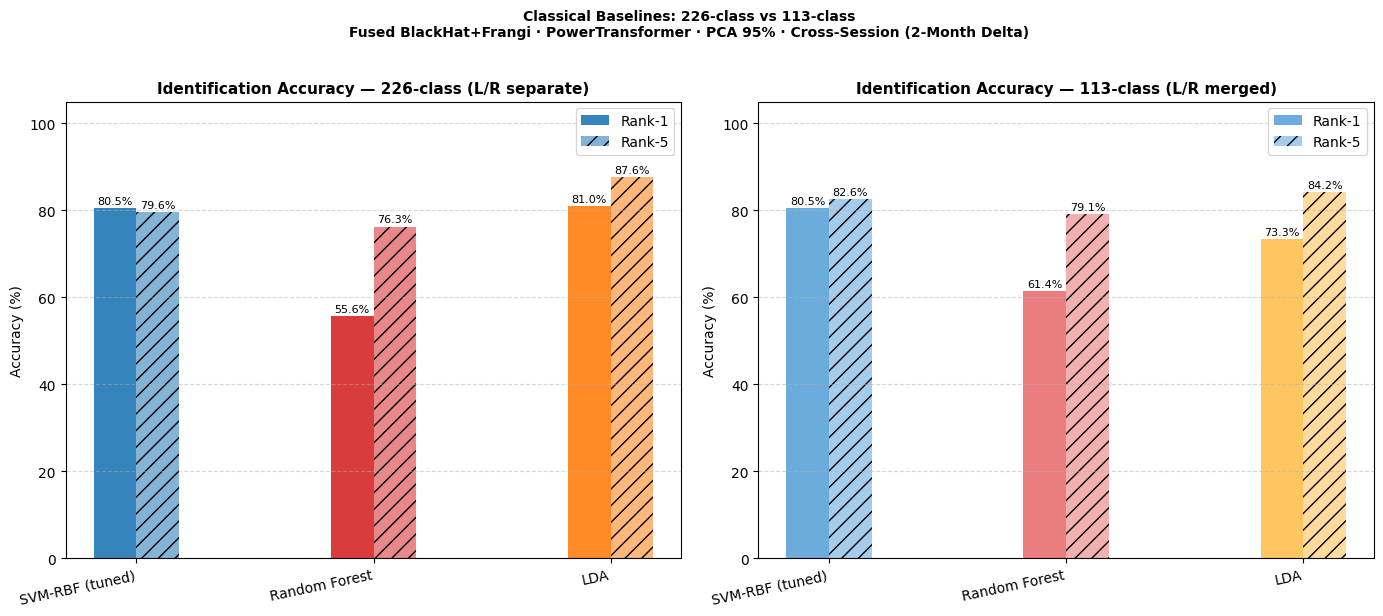

✓ Bar chart saved.


In [ ]:
# =========================================================================
# CELL 6: SIDE-BY-SIDE RANK-1 / RANK-5 BAR CHART  (226 vs 113)
# =========================================================================
import matplotlib.pyplot as plt
import numpy as np

model_names = ["SVM-RBF (tuned)", "Random Forest", "LDA"]
colors_226  = ['#1f77b4', '#d62728', '#ff7f0e']
colors_113  = ['#5ba3d9', '#e87070', '#ffc04d']

r1_226 = [results_226[m]["Rank-1"] for m in model_names]
r5_226 = [results_226[m]["Rank-5"] for m in model_names]
r1_113 = [results_113[m]["Rank-1"] for m in model_names]
r5_113 = [results_113[m]["Rank-5"] for m in model_names]

x = np.arange(len(model_names))
width = 0.18

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, r1, r5, scheme, clrs in [
        (axes[0], r1_226, r5_226, "226-class (L/R separate)", colors_226),
        (axes[1], r1_113, r5_113, "113-class (L/R merged)",   colors_113)]:
    b1 = ax.bar(x - width/2, r1, width, label='Rank-1', color=clrs,          alpha=0.90)
    b2 = ax.bar(x + width/2, r5, width, label='Rank-5', color=clrs, hatch='//', alpha=0.55)
    ax.set_title(f'Identification Accuracy — {scheme}', fontsize=11, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=12, ha='right')
    ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 105)
    ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.5)
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.5,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle(
    'Classical Baselines: 226-class vs 113-class\n'
    'Fused BlackHat+Frangi · PowerTransformer · PCA 95% · Cross-Session (2-Month Delta)',
    fontsize=10, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_226_vs_113.png'), dpi=200, bbox_inches='tight')
plt.show()
print("✓ Bar chart saved.")

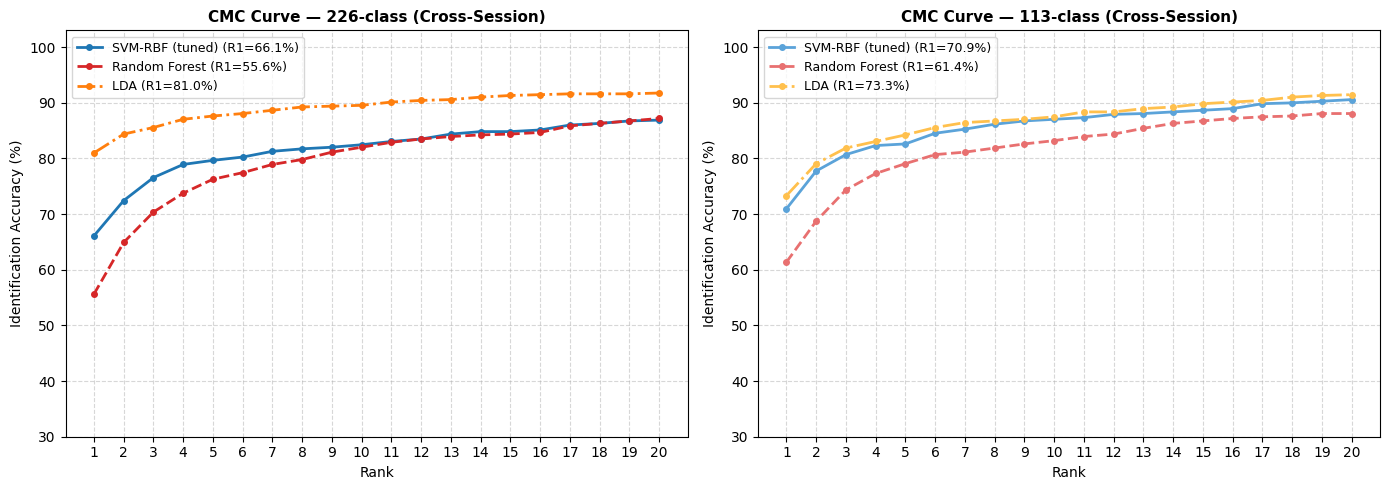

✓ CMC curves saved.


In [ ]:
# =========================================================================
# CELL 7: CMC CURVES — ALL MODELS, BOTH SCHEMES
# =========================================================================
import matplotlib.pyplot as plt, numpy as np

max_ranks = 20
ranks = list(range(1, max_ranks + 1))

ls  = {'SVM-RBF (tuned)': '-',  'Random Forest': '--', 'LDA': '-.'}
c226= {'SVM-RBF (tuned)': '#1f77b4', 'Random Forest': '#d62728', 'LDA': '#ff7f0e'}
c113= {'SVM-RBF (tuned)': '#5ba3d9', 'Random Forest': '#e87070', 'LDA': '#ffc04d'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, results, scheme, clr_map in [
        (axes[0], results_226, "226-class", c226),
        (axes[1], results_113, "113-class", c113)]:
    for mname in ["SVM-RBF (tuned)", "Random Forest", "LDA"]:
        res = results[mname]
        y_proba, y_test_enc = res["y_proba"], res["y_test_enc"]
        cmc = [
            sum(1 for i in range(len(y_test_enc))
                if y_test_enc[i] in np.argsort(y_proba[i])[-r:])
            / len(y_test_enc) * 100
            for r in ranks
        ]
        ax.plot(ranks, cmc, marker='o', markersize=4, linewidth=2,
                color=clr_map[mname], linestyle=ls[mname],
                label=f"{mname} (R1={cmc[0]:.1f}%)")
    ax.set_title(f'CMC Curve — {scheme} (Cross-Session)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Rank'); ax.set_ylabel('Identification Accuracy (%)')
    ax.set_xticks(ranks); ax.set_ylim(30, 103)
    ax.grid(True, linestyle='--', alpha=0.5); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cmc_226_vs_113.png'), dpi=200, bbox_inches='tight')
plt.show()
print("✓ CMC curves saved.")

In [ ]:
# =========================================================================
# CELL 8: BINARY VERIFICATION (EER / AUC) — BOTH SCHEMES
# =========================================================================
import numpy as np, random
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve, auc
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

np.random.seed(42); random.seed(42)


def calculate_eer(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores, pos_label=1)
    fnr = 1 - tpr
    try:
        eer = brentq(lambda x: interp1d(fpr, fnr)(x) - x, 0.0, 1.0)
    except ValueError:
        eer = fpr[np.nanargmin(np.absolute(fpr - fnr))]
    return eer * 100


def run_verification(results_dict, X_train_raw, y_train_raw,
                     X_test_raw,  y_test_raw,  scheme_name,
                     n_identities=15):
    """Re-uses the pt + pca fitted in Cell 5 — no new leakage."""
    ref = list(results_dict.values())[0]
    X_tr = ref['pca'].transform(ref['pt'].transform(X_train_raw))
    X_te = ref['pca'].transform(ref['pt'].transform(X_test_raw))

    unique_ids = sorted(set(y_train_raw))
    test_ids   = unique_ids[:n_identities]

    bin_models = {
        "SVM-RBF" : SVC(kernel='rbf', C=10.0, gamma='scale',
                        probability=True, random_state=42),
        "RF"      : RandomForestClassifier(n_estimators=400,
                        random_state=42, n_jobs=-1),
        "LDA"     : LinearDiscriminantAnalysis(solver='svd')
    }
    all_res = {n: {"EER": [], "AUC": []} for n in bin_models}

    for tid in test_ids:
        tr_gen = np.where(y_train_raw == tid)[0]
        tr_imp = np.where(y_train_raw != tid)[0]
        te_gen = np.where(y_test_raw  == tid)[0]
        te_imp = np.where(y_test_raw  != tid)[0]

        tr_imp_s = np.random.choice(tr_imp, size=len(tr_gen), replace=False)
        te_imp_s = np.random.choice(te_imp, size=len(te_gen), replace=False)

        tr_idx = np.concatenate([tr_gen, tr_imp_s])
        te_idx = np.concatenate([te_gen, te_imp_s])

        X_tr_b = X_tr[tr_idx]; y_tr_b = np.where(y_train_raw[tr_idx] == tid, 1, 0)
        X_te_b = X_te[te_idx]; y_te_b = np.where(y_test_raw[te_idx]  == tid, 1, 0)

        for mname, clf in bin_models.items():
            clf.fit(X_tr_b, y_tr_b)
            scores = clf.predict_proba(X_te_b)[:, 1]
            fp, tp, _ = roc_curve(y_te_b, scores)
            all_res[mname]["AUC"].append(auc(fp, tp))
            all_res[mname]["EER"].append(calculate_eer(y_te_b, scores))

    print(f"\n{'='*65}")
    print(f"  VERIFICATION — {scheme_name}")
    print(f"{'='*65}")
    for mname in bin_models:
        print(f"  {mname:<12}  Avg EER: {np.mean(all_res[mname]['EER']):6.2f}%   "
              f"Avg AUC: {np.mean(all_res[mname]['AUC']):.4f}")
    print(f"{'='*65}")
    return all_res


ver_226 = run_verification(results_226, X_train_226, y_train_226,
                           X_test_226, y_test_226, "226-CLASS")

ver_113 = run_verification(results_113, X_train_113, y_train_113,
                           X_test_113, y_test_113, "113-CLASS")


  VERIFICATION — 226-CLASS
  SVM-RBF       Avg EER:   8.89%   Avg AUC: 0.9185
  RF            Avg EER:  13.33%   Avg AUC: 0.8741
  LDA           Avg EER:  53.33%   Avg AUC: 0.4370

  VERIFICATION — 113-CLASS
  SVM-RBF       Avg EER:  11.11%   Avg AUC: 0.9093
  RF            Avg EER:  16.67%   Avg AUC: 0.8889
  LDA           Avg EER:  54.44%   Avg AUC: 0.4278


In [ ]:
# =========================================================================
# CELL 9: SUMMARY TABLE — ALL METRICS, BOTH SCHEMES
# =========================================================================
import pandas as pd, numpy as np

model_map = {"SVM-RBF (tuned)": "SVM-RBF", "Random Forest": "RF", "LDA": "LDA"}

rows = []
for scheme, res_id, res_ver in [
        ("226-class", results_226, ver_226),
        ("113-class", results_113, ver_113)]:
    for mname in ["SVM-RBF (tuned)", "Random Forest", "LDA"]:
        vk = model_map[mname]
        rows.append({
            "Scheme"  : scheme,
            "Model"   : mname,
            "Rank-1 %": f"{res_id[mname]['Rank-1']:.2f}",
            "Rank-5 %": f"{res_id[mname]['Rank-5']:.2f}",
            "Avg EER %": f"{np.mean(res_ver[vk]['EER']):.2f}",
            "Avg AUC"  : f"{np.mean(res_ver[vk]['AUC']):.4f}",
        })

df = pd.DataFrame(rows)
print("\n" + "="*72)
print("  FULL RESULTS SUMMARY  (Cross-Session, 2-Month Delta)")
print("="*72)
print(df.to_string(index=False))
print("="*72)

csv_path = os.path.join(RESULTS_DIR, 'full_results_summary.csv')
df.to_csv(csv_path, index=False)
print(f"\n✓ Results table saved → {csv_path}")


  FULL RESULTS SUMMARY  (Cross-Session, 2-Month Delta)
   Scheme           Model Rank-1 % Rank-5 % Avg EER % Avg AUC
226-class SVM-RBF (tuned)    80.53    79.65      8.89  0.9185
226-class   Random Forest    55.60    76.25     13.33  0.8741
226-class             LDA    80.97    87.61     53.33  0.4370
113-class SVM-RBF (tuned)    80.53    82.60     11.11  0.9093
113-class   Random Forest    61.36    79.06     16.67  0.8889
113-class             LDA    73.30    84.22     54.44  0.4278

✓ Results table saved → /content/drive/MyDrive/DorsalVeinProject/results/full_results_summary.csv
